# fe_02. Lag features si rolling features - memoria modelului

**Pregatire SCSS 2026 - Diana Nenu**

Notebook care explica concret cum dam **memorie** unui model de Machine Learning pe time series. Doua tehnici complementare:
- **Lag features** - puncte exacte din trecut (acum 1h, 24h, 168h)
- **Rolling features** - statistici pe ferestre alunecatoare (medie, deviatie)

Vom lucra pe date sintetice tip pret energetic Spania, dar tehnicile sunt aceleasi pentru orice time series.

## 2.1 Setup si date

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

In [2]:
# Generez ~14 zile de pret energetic orar (336 ore)
n = 336
rng = np.random.default_rng(42)
t = np.arange(n)
# Sezonalitate zilnica (varf seara), trend usor, zgomot
pret = (50 + 8 * np.cos(2 * np.pi * (t % 24 - 19) / 24)
        + 3 * np.cos(2 * np.pi * t / (24*7))   # sezonalitate saptamanala
        + np.cumsum(rng.normal(0, 0.15, n)))   # drift aleator
df = pd.DataFrame({'pret': pret})
df.index.name = 'ora'
print(df.head(10))

          pret
ora           
0    55.116260
1    52.887612
2    50.923337
3    49.124499
4    47.160345
5    45.674876
6    44.871933
7    44.524897
8    44.763911
9    45.400090


## 2.2 Fundamentul teoretic - autoregresivitatea

Inainte de a introduce lag features, sa intelegem **de ce functioneaza** ele matematic.

O serie temporala este **autoregresiva** daca valorile ei viitoare pot fi prezise folosind propriile valori trecute. Cel mai simplu model este **AR(1)**:

$$y_t = c + \varphi \cdot y_{t-1} + \varepsilon_t$$

unde $\varphi$ (phi) este coeficientul de autoregresie. Cu cat $|\varphi|$ e mai aproape de 1, cu atat seria este **mai puternic autoregresiva** — adica valoarea curenta este mai bine prezisa de valoarea anterioara.

**Demonstratie interactiva**: misca sliderul pentru $\varphi$ de la 0 (zgomot pur) la 0.99 (autoregresivitate aproape perfecta) si observa cum se schimba seria si scatter-ul t-1 vs t.

In [3]:
from ipywidgets import interact, FloatSlider

def ar_interactiv(phi):
    rng = np.random.default_rng(42)
    n = 200
    y = np.zeros(n)
    y[0] = 50
    # Genereaza AR(1) cu phi dat
    for i in range(1, n):
        y[i] = phi * y[i-1] + (1 - phi) * 50 + rng.normal(0, 0.8)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Stanga - seria
    axes[0].plot(y, '-', color='#065A82', lw=1.5, alpha=0.85)
    axes[0].scatter(range(n), y, s=15, color='#065A82', alpha=0.7)
    axes[0].set_title(f'Seria AR(1) cu phi = {phi:.2f}',
                       fontsize=13, fontweight='bold')
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('y(t)')
    axes[0].grid(alpha=0.3)

    # Dreapta - scatter t-1 vs t
    corr = np.corrcoef(y[:-1], y[1:])[0, 1]
    axes[1].scatter(y[:-1], y[1:], s=30, color='#065A82', alpha=0.6,
                    edgecolor='white', linewidth=0.5)
    lims = [y.min() - 1, y.max() + 1]
    axes[1].plot(lims, lims, '--', color='#F96167', lw=2, label='y = x')
    axes[1].set_xlabel('y(t-1)')
    axes[1].set_ylabel('y(t)')
    axes[1].set_title(f'Scatter t-1 vs t  |  Corelatia Pearson = {corr:+.3f}',
                       fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

interact(ar_interactiv,
         phi=FloatSlider(min=0.0, max=0.99, step=0.05, value=0.95,
                         description='phi:', readout_format='.2f'));

interactive(children=(FloatSlider(value=0.95, description='phi:', max=0.99, step=0.05), Output()), _dom_classe…

**Ce sa observi**:
- La $\varphi = 0$: seria este zgomot pur, scatter-ul este o pata difuza, corelatia ≈ 0.
- La $\varphi = 0.5$: seria are 'memorie' moderata, scatter-ul incepe sa se alinieze.
- La $\varphi = 0.95$: seria este puternic autoregresiva, scatter-ul este aproape pe diagonala — exact ca in datele tale energetice unde corelatia este ~0.99.

**Insight cheie**: lag features (sectiunea urmatoare) functioneaza tocmai pentru ca seriile energetice reale au $\varphi$ aproape de 1 — predictia la t este aproape determinata de valoarea de la t−1.

## 2.3 Lag features - memoria scurta

**Idea de baza**: pretul peste o ora va fi probabil aproape de pretul actual. Cererea si oferta nu se schimba brusc.

**Implementare**: functia `shift` din pandas muta coloana cu un decalaj fix. `shift(1)` ne da valoarea cu o pozitie inainte; `shift(24)` cu 24 de pozitii inainte; etc.

Pe date energetice, valorile canonice de lag sunt:
- **lag_1** (1 ora) - corelatia cea mai puternica, autoregresivitate de scurta durata
- **lag_24** (1 zi) - ce era exact la aceeasi ora ieri
- **lag_168** (1 saptamana = 7 × 24) - pattern saptamanal

In [4]:
# Construiesc lag features
for h in [1, 24, 168]:
    df[f'lag_{h}'] = df['pret'].shift(h)

# Afisez primele randuri (cu NaN-uri la inceput)
print(df.head(3))
print('...')
print(df.iloc[24:27])  # aici lag_24 incepe sa aiba valori, lag_168 inca NaN
print('...')
print(df.iloc[170:173])  # aici toate au valori

          pret      lag_1  lag_24  lag_168
ora                                       
0    55.116260        NaN     NaN      NaN
1    52.887612  55.116260     NaN      NaN
2    50.923337  52.887612     NaN      NaN
...
          pret      lag_1     lag_24  lag_168
ora                                          
24   53.808309  55.888399  55.116260      NaN
25   51.595928  53.808309  52.887612      NaN
26   49.513722  51.595928  50.923337      NaN
...
          pret      lag_1     lag_24    lag_168
ora                                            
170  49.453440  51.628501  48.669369  50.923337
171  47.580428  49.453440  46.799605  49.124499
172  45.840682  47.580428  45.380483  47.160345


**Observatie tehnica**: `shift(168)` creeaza 168 de NaN-uri la inceputul seriei. Acestea trebuie eliminate (`.dropna()`) inainte de antrenare. Pe seria mea reala Spania (35.000 ore), pierd 168 randuri - neglijabil.

## 2.4 Vizualizare: pretul real vs lag_1

Vom vedea ca lag_1 este aproape o copie a pretului real, doar deplasata cu o pozitie. Tocmai de aceea lag_1 e atat de informativ pentru predictie.

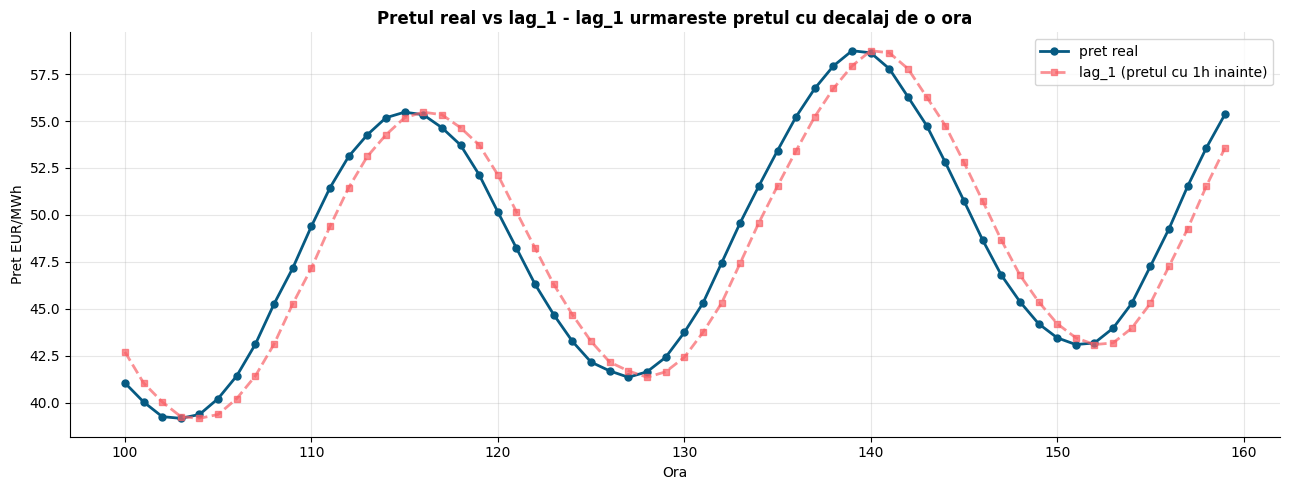

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
subset = df.iloc[100:160]  # 60 ore = aprox 2.5 zile
ax.plot(subset.index, subset['pret'], 'o-', color='#065A82', lw=2,
        markersize=5, label='pret real')
ax.plot(subset.index, subset['lag_1'], 's--', color='#F96167', lw=2,
        markersize=5, label='lag_1 (pretul cu 1h inainte)', alpha=0.7)
ax.set_xlabel('Ora')
ax.set_ylabel('Pret EUR/MWh')
ax.set_title('Pretul real vs lag_1 - lag_1 urmareste pretul cu decalaj de o ora',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.5 Cat de bun predictor este lag_1?

Calculez **corelatia Pearson** intre pret si lag_1, si intre pret si lag_24, ca masura simpla a puterii predictive a fiecaruia.

In [6]:
valid = df.dropna()
for col in ['lag_1', 'lag_24', 'lag_168']:
    corr = valid['pret'].corr(valid[col])
    print(f'Corelatia pret vs {col:<8}: {corr:.4f}')

Corelatia pret vs lag_1   : 0.9708
Corelatia pret vs lag_24  : 0.9399
Corelatia pret vs lag_168 : 0.9892


In datele tale reale Spania, **price_lag_1 avea corelatie ~0.99** cu pretul curent. Asta inseamna ca, in medie, pretul peste o ora difera de pretul actual cu mai putin de 1%. Asta e si motivul tehnic pentru care lag_1 explica peste 90% din decizia modelului XGBoost in capitolul 5.4 al disertatiei mele.

## 2.6 Rolling features - trend si volatilitate

Lag-urile dau puncte exacte din trecut. **Rolling features** combina mai multe puncte intr-o statistica agregata.

Doua tipuri principale:
- **rolling mean** - media ultimelor N ore. Captureaza trend-ul (directia generala).
- **rolling std** - deviatia standard. Captureaza volatilitatea (cat de stabil e sistemul).

**IMPORTANT**: aici e momentul critic. Implementarea naiva (`df['pret'].rolling(N).mean()`) introduce un bug subtil pe care il vom vedea in notebook-ul urmator. **Pentru moment**, folosim varianta corecta cu `.shift(1)`.

In [7]:
# Rolling features CORECTE - cu shift(1) inainte
df['roll_mean_3']  = df['pret'].shift(1).rolling(3).mean()
df['roll_mean_24'] = df['pret'].shift(1).rolling(24).mean()
df['roll_std_24']  = df['pret'].shift(1).rolling(24).std()

print(df.iloc[170:178][['pret', 'roll_mean_3', 'roll_mean_24', 'roll_std_24']].round(2))

      pret  roll_mean_3  roll_mean_24  roll_std_24
ora                                               
170  49.45        53.66         51.28         5.97
171  47.58        51.60         51.31         5.96
172  45.84        49.55         51.34         5.94
173  44.37        47.62         51.36         5.92
174  43.35        45.93         51.37         5.91
175  43.08        44.52         51.36         5.91
176  43.56        43.60         51.36         5.91
177  44.35        43.33         51.38         5.89


## 2.7 Vizualizare: pret real + lag + rolling mean

Trei perspective complementare ale aceleeasi serii:

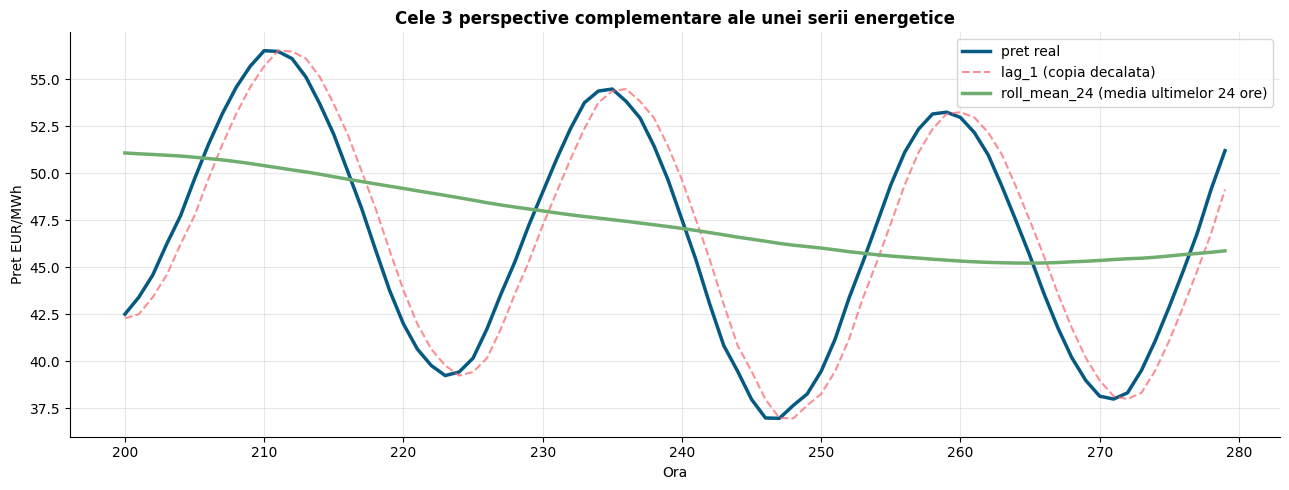

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
subset = df.iloc[200:280]
ax.plot(subset.index, subset['pret'], '-', color='#065A82', lw=2.5, label='pret real')
ax.plot(subset.index, subset['lag_1'], '--', color='#F96167', lw=1.5,
        label='lag_1 (copia decalata)', alpha=0.7)
ax.plot(subset.index, subset['roll_mean_24'], '-', color='#6FAE6F', lw=2.5,
        label='roll_mean_24 (media ultimelor 24 ore)')
ax.set_xlabel('Ora')
ax.set_ylabel('Pret EUR/MWh')
ax.set_title('Cele 3 perspective complementare ale unei serii energetice',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Citire grafic:**
- **Albastru (pret real)** - ce vrem sa prezicem. Are oscilatii zilnice clare.
- **Coral (lag_1)** - copia pretului decalata cu o ora. Urmareste oscilatiile cu decalaj.
- **Verde (roll_mean_24)** - media ultimelor 24 ore. Linie neteda care arata nivelul de fond, fara salturile zilnice.

**De ce sunt complementare?** Lag-ul ne spune 'unde era ieri la aceeasi ora', media ne spune 'unde a fost in general in ultima zi'. Modelul foloseste ambele perspective pentru a prezice.

## 2.8 Concluzii

1. **Lag features** dau modelului punct-de-vedere exact: 'valoarea de acum o ora era X'.
2. **Rolling features** dau modelului context agregat: 'media ultimelor 24 ore era Y, deviatia Z'.
3. Pe date energetice, **lag_1 este de departe cel mai informativ feature** - corelatia este aproape de 1 cu pretul curent.
4. Cele doua tipuri se completeaza - lag spune detalii punctuale, rolling spune contextul general.
5. **ATENTIE** la `.shift(1)` la rolling - urmatorul notebook arata exact ce se intampla fara el si de ce e o capcana critica.

**Urmatorul notebook**: demonstratia faptului ca rolling fara shift(1) duce la data leakage si R² fals.